## **The purpose of this notebook is to examine post-treatment (D0 → D5-post) changes in DMN-LIM functional connectivity during the acute phase.**

In [ ]:
# Import core data science and statistical libraries
import pandas as pd
import numpy as np
import os,re
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="Random effects covariance is singular")
warnings.simplefilter(action='ignore', category=FutureWarning)
import seaborn as sns
sns.set(font_scale=1.5,style="white")
import matplotlib.pyplot as plt
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy.stats import pearsonr,wilcoxon,ttest_ind
from tqdm import tqdm
import ptitprince as pt
import matplotlib.pyplot as plt
# Custom color palette for responder vs non-responder groups
res_colors = ['#E6194B','#4363D8']


In [ ]:
import statsmodels.api as sm

# Apply FDR (Benjamini-Hochberg) correction to a list of p-values
def FDR_correct(p_values):
    return sm.stats.multipletests(p_values, alpha=0.05, method='fdr_bh')[1]


In [ ]:
# Load BOLD time series for both cortical (Schaefer) and subcortical (HCP) ROIs
def read_bold(sub,ses):
    bold_ctx = pd.read_csv(f"/data/dy/TIS_MDD/BOLD/{sub}/{ses}/{schaefer}.csv")
    bold_sub = pd.read_csv(f"/data/dy/TIS_MDD/BOLD/{sub}/{ses}/hcp.csv")
    bold = pd.concat([bold_ctx,bold_sub],axis=1)
    return bold


In [ ]:
# Compute FC matrix and average connectivity between each RSN pair and subcortical ROIs
def fc_roi_to_rsn(bold):
    fc = pd.DataFrame(np.corrcoef(bold.T), index = bold.columns, columns = bold.columns)
    result = pd.DataFrame(np.zeros((8,8)),
                          index = rsn_ls+['Sub'], 
                          columns = rsn_ls+['Sub'])
    for i in range(len(rsn_ls)):
        rois_i = atlas[atlas['ICN'] == rsn_ls[i]]['Name'].tolist()
        # Mean FC from this RSN to all subcortical ROIs
        result.loc[rsn_ls[i],'Sub'] = np.mean(fc.loc[rois_i,subctx_rois])
        result.loc['Sub',rsn_ls[i]] = np.mean(fc.loc[rois_i,subctx_rois])
        # Mean FC between RSN pairs (upper triangle symmetric)
        for j in range(i,len(rsn_ls)):
            rois_j = atlas[atlas['ICN'] == rsn_ls[j]]['Name'].tolist()
            result.loc[rsn_ls[i],rsn_ls[j]] = np.mean(fc.loc[rois_i,rois_j])
            result.loc[rsn_ls[j],rsn_ls[i]] = np.mean(fc.loc[rois_i,rois_j])
    # Within-subcortical mean FC
    result.loc['Sub','Sub'] = np.mean(fc.loc[subctx_rois,subctx_rois])
    return result


In [ ]:
# Plot RainCloud with group means for session × responder interaction
def plot_interaction(df,y_col,ses_id,pvalues,x_col = 'session',hue = 'responder', xticks = None,xlabel = '', ylabel = '', title = '',F=0):
    xticks = ['baseline',ses_id] if xticks == None else xticks
    fig, ax = plt.subplots(figsize=(6,5),dpi=300)
    # RainCloud grouped by session and responder status
    pt.RainCloud(x=x_col, y=y_col, data=df, 
                 order=['baseline',ses_id], palette=res_colors,hue='responder',
                 bw=.15, width_viol=1.2, width_box=0.0, offset=.0,alpha=.75, move=0.15, ax=ax, orient='v',point_size = 0,
                 dodge=True,box_linewidth=0,linewidth=0,box_showfliers=False)
    # Remove unnecessary whisker lines
    for line in ax.get_lines():
        if 'whisker' in str(line) or line.get_linestyle() == '-':
            line.set_linewidth(0)
    
    plt.xlim(-0.9,1.5)
    # Plot group mean trajectories for responder and non-responder
    for i,res in enumerate(['responder','non-responder']):
        res_df = df[df['responder'] == res]
        y = res_df.groupby(x_col)[y_col].mean().reindex(['baseline',ses_id])
        x = np.arange(len(y))
        plt.plot(x,y,color = res_colors[i], linewidth = 3,
                marker='o',markersize=8,markeredgecolor='black',markerfacecolor=res_colors[i],markeredgewidth=1.5)
    
    # Add interaction F/p-value annotation
    ymax = np.max(df[y_col]);ymin = np.min(df[y_col]);yrange = ymax - ymin
    plt.ylim(ymin-0.1*yrange,ymax + 0.2*yrange)
    plt.text(0.2,ymax + 0.1*yrange,f"F={F:.3f} $p_{{interaction}}={pvalues:.3f}$", ha = 'center', va = 'center')
    handles = [
    mpatches.Patch(color='#E6194B', label='responder'),
    mpatches.Patch(color='#4363D8', label='non-responder')]
    ax.legend(handles=handles,bbox_to_anchor=(1, 1.13),
                  loc='upper right', ncol=2, frameon=False, fontsize=15)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title, y= 1.1)
    plt.xticks(np.arange(len(xticks)),xticks)


# Plot scatter with regression line, colored by responder status
def plot_corr_responder(df,x_col,y_col,text='',xlabel='',ylabel='',title=''):
    fig,ax = plt.subplots(figsize = (7,5.5),dpi = 300)
    # Overall regression line with 95% CI (invisible scatter)
    sns.regplot(data=df,x=x_col,y=y_col,ci=95, 
                scatter_kws={"facecolors": "#262626","edgecolor": "#262626","s": 20,'alpha':0},
                line_kws={"color": '#cc79f4', 'linewidth': 6} )
    # Scatter points colored by responder vs non-responder
    plt.scatter(data=df[df['responder']=='responder'],x=x_col,y=y_col,color=res_colors[0],label='responder',s=90,edgecolor = 'black', alpha = 0.8, linewidth = 1.25)
    plt.scatter(data=df[df['responder']!='responder'],x=x_col,y=y_col,color=res_colors[1],label='non-responder',s=90, edgecolor = 'black', alpha = 0.8, linewidth = 1.25)
    # Set axis limits with padding
    x_max = np.max(df[x_col]);x_min = np.min(df[x_col]);x_range=x_max-x_min
    y_max = np.max(df[y_col]);y_min = np.min(df[y_col]);y_range=y_max-y_min
    plt.xlim(x_min-x_range*.1,x_max+x_range*.1)
    plt.ylim(y_min-y_range*.1,y_max+y_range*.1)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title,y = 1.15)
    plt.legend(bbox_to_anchor=(0, 1.15), loc='upper left', frameon=False,handlelength=0.8,handletextpad=0.3,ncol=2)


In [ ]:
# Load clinical scale data and standardize column names
madrs = pd.read_csv('/data/dy/TIS_MDD/Scales/madrs.csv',index_col='sub').loc[:,['condition','MADRS_all']] ## MADRS_all
hamd = pd.read_csv('/data/dy/TIS_MDD/Scales/hamd.csv',index_col='sub').loc[:,['condition','HAMD_all']] ## HAMD_all
qids = pd.read_csv('/data/dy/TIS_MDD/Scales/qids.csv',index_col='sub').loc[:,['condition','QIDS_all']] ## QIDS_all
hama = pd.read_csv('/data/dy/TIS_MDD/Scales/hama.csv',index_col='sub').loc[:,["condition","HAMA_all"]] ## HAMA_all
psqi = pd.read_csv('/data/dy/TIS_MDD/Scales/psqi.csv',index_col='sub').loc[:,["condition","PSQI_ALL"]] ## PSQI_ALL
# Rename columns for consistency and fix timepoint labels
madrs.columns = ['timepoint','MADRS']
madrs.iloc[1,0] = '5th'
hama.iloc[1,0] = '5th'
hamd.columns = ['timepoint','HAMD']
qids.columns = ['timepoint','QIDS']
hama.columns = ['timepoint','HAMA']
psqi.columns = ['timepoint','PSQI']

col_dict = {'MADRS':madrs,'HAMD':hamd,'QIDS':qids,"HAMA":hama,"PSQI":psqi}
import pingouin as pg

# Load demographic data and create sex dummy variable
demo_info = pd.read_csv('/data/dy/TIS_MDD/demo_info.csv',index_col=0)
demo_info['sub_id'] = demo_info.index
demo_info['sex_id'] = [1 if i=='M' else 0 for i in demo_info['sex']]

# Match scale data for a given timepoint and re-label for mixed-model analysis
def match_scale(data, timepoint):
    scale = data.copy()
    scale.loc[:,'ID'] = scale.index
    scale.index = np.arange(scale.shape[0])
    # Standardize timepoint names
    scale.loc[scale[scale['timepoint'] == 'pre'].index,'timepoint'] = 'baseline'
    scale.loc[scale[scale['timepoint'] == '5th'].index,'timepoint'] = '5th_after'
    scale.loc[scale[scale['timepoint'] == '4week'].index,'timepoint'] = '4weeks'
    
    # Group by (timepoint, subject) and extract baseline + target timepoint
    scale_group = scale.groupby(['timepoint','ID'])
    df = []
    for con in ['baseline',timepoint]:
        for sub in responder.index:
            df.append(scale_group.get_group((con,sub)))
    
    df = pd.concat(df)
    df.index = [f"{df.loc[i,'ID']}_{df.loc[i,'timepoint']}" for i in df.index]
    return df


In [ ]:
# Load responder status, demographic data, and atlas definitions
responder = pd.read_csv(f"/data/dy/TIS_MDD/responder.csv", index_col = 0)

# Subject sub-010 was excluded due to an average head motion exceeding 0.5 mm.
responder = responder.drop("sub-010", axis = 0)
demo = pd.read_csv(f"/data/dy/TIS_MDD/demo_info.csv", index_col = 'sub')

# Define session labels, RSN names, atlas resolution, and subcortical ROIs (excluding amygdala, brainstem, etc.)
ses_ls = ['baseline','5th_201','5th_301','5th_after','4weeks']
rsn_ls = ['Vis','SomMot','SalVentAttn','DorsAttn','Default','Cont','Limbic']
schaefer = 100
atlas = pd.read_csv(f"/data/dy/atlas/upgrade/Schaefer{schaefer}x7_MNI.csv")
subctx_rois = pd.read_csv(f"/data/dy/TIS_MDD/BOLD/sub-001/1st_201/hcp.csv").columns.tolist()
subctx_rois.remove("AMYGDALA_RIGHT")
subctx_rois.remove("BRAIN_STEM")
subctx_rois.remove("DIENCEPHALON_VENTRAL_LEFT")
subctx_rois.remove("DIENCEPHALON_VENTRAL_RIGHT")
subctx_rois.remove("CEREBELLUM_RIGHT")
subctx_rois.remove("CEREBELLUM_LEFT")


In [ ]:
# Compute RSN-level FC (using Limbic as seed) for every subject × session
X_rsn = 'Limbic'
fc_df = pd.DataFrame(dtype = float, columns = rsn_ls + ['Sub','id','session','sex','age','responder'])
for sub in tqdm(responder.index, ncols = 100):
    for ses in ses_ls:
        # Load BOLD and compute RSN × subcortical FC matrix
        bold = read_bold(sub,ses)
        fc = fc_roi_to_rsn(bold)
        # Extract FC from the seed RSN (Limbic) to all targets
        idx = f"{sub}_{ses}"
        fc_df.loc[idx,rsn_ls + ['Sub']] = np.array(fc.loc[X_rsn,:])
        # Annotate with subject ID, session, demographics, and responder status
        fc_df.loc[idx,['id','session']] = sub,ses
        fc_df.loc[idx,['sex','age']] = demo.loc[sub,:].tolist()
        fc_df.loc[idx,['responder']] = responder.loc[sub,'responder']


100%|███████████████████████████████████████████████████████████████| 26/26 [00:11<00:00,  2.28it/s]


In [ ]:
# Mixed-effects model: test session, interaction (session×responder), and FDR correction
LME_result = pd.DataFrame(columns = ['session','rsn','p_session','p_interaction','F_interaction'], dtype = float)
for ses in tqdm(ses_ls[1:], ncols = 100):
    df = fc_df[fc_df['session'].isin(['baseline',ses])]
    for rsn in rsn_ls+['Sub']:
        # Model: FC ~ session * responder + sex + age, with subject as random intercept
        model = smf.mixedlm(f"{rsn}~session*responder + sex + age", data = df, groups = df['id']).fit()
        F = model.wald_test_terms().summary_frame().iloc[4,0][0][0]
        LME_result.loc[f"{ses}_{rsn}",['session','rsn','p_session','p_interaction']] = ses,rsn,model.pvalues[1],model.pvalues[4]
        LME_result.loc[f"{ses}_{rsn}",['F_interaction']] = F
        if(model.pvalues[4]<0.05):
            print(model.summary())
    # FDR correction across RSNs within each session
    idx = LME_result[LME_result['session'] == ses].index
    LME_result.loc[idx,'FDR_session'] = FDR_correct(LME_result.loc[idx,'p_session'])
    LME_result.loc[idx,'FDR_interaction'] = FDR_correct(LME_result.loc[idx,'p_interaction'])

# Print significant interaction effects (uncorrected p < 0.05)
print(LME_result[LME_result['p_interaction']<0.05].sort_values(by = "p_interaction"))


 25%|████████████████▎                                                | 1/4 [00:00<00:01,  1.94it/s]

                        Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          SalVentAttn
No. Observations:           52               Method:                      REML       
No. Groups:                 26               Scale:                       0.0054     
Min. group size:            2                Log-Likelihood:              39.5231    
Max. group size:            2                Converged:                   Yes        
Mean group size:            2.0                                                      
-------------------------------------------------------------------------------------
                                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------
Intercept                                  -0.029    0.051 -0.564 0.573 -0.128  0.071
session[T.baseline]                        -0.085    0.030 -2.832 0.005 -0.144

 50%|████████████████████████████████▌                                | 2/4 [00:01<00:01,  1.84it/s]

                        Mixed Linear Model Regression Results
Model:                        MixedLM           Dependent Variable:           Default
No. Observations:             52                Method:                       REML   
No. Groups:                   26                Scale:                        0.0031 
Min. group size:              2                 Log-Likelihood:               56.6730
Max. group size:              2                 Converged:                    Yes    
Mean group size:              2.0                                                    
-------------------------------------------------------------------------------------
                                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------
Intercept                                   0.155    0.032  4.855 0.000  0.092  0.218
session[T.baseline]                         0.043    0.023  1.874 0.061 -0.002

100%|█████████████████████████████████████████████████████████████████| 4/4 [00:02<00:00,  1.59it/s]

                       session          rsn  p_session  p_interaction  \
5th_301_SalVentAttn    5th_301  SalVentAttn   0.004631       0.003555   
5th_after_Default    5th_after      Default   0.060926       0.034687   

                     F_interaction  FDR_session  FDR_interaction  
5th_301_SalVentAttn       8.498222     0.037049         0.028439  
5th_after_Default         4.460539     0.315123         0.224444  


### **LIM - D5-post - Interaction** 

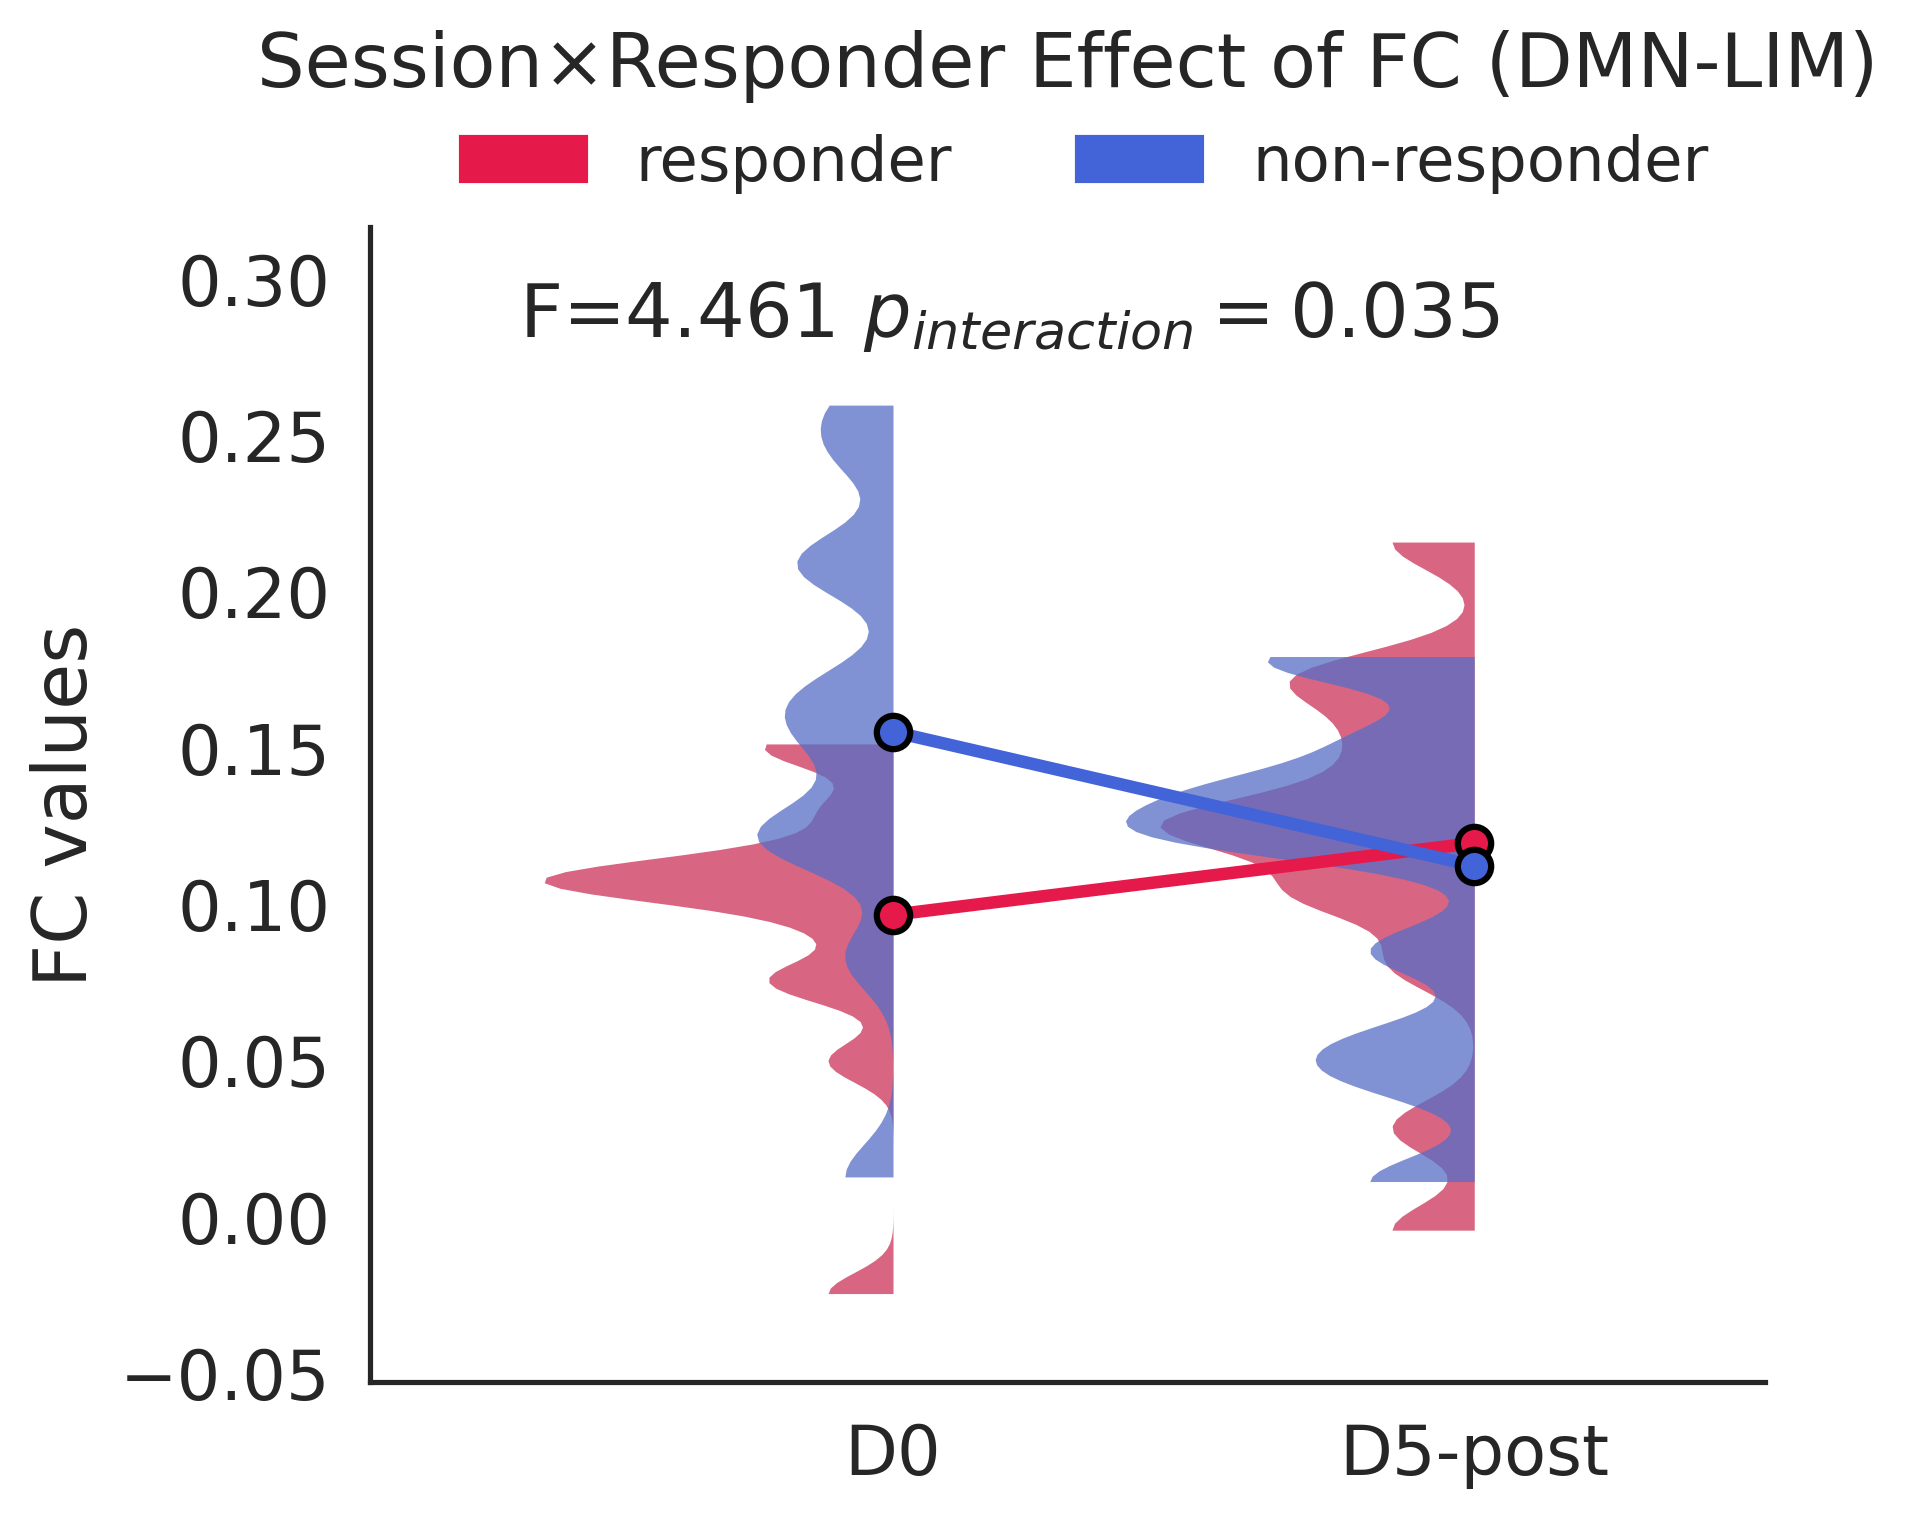

In [ ]:
# Plot the significant session×responder interaction for DMN-LIM FC
ses = '5th_after'
rsn = 'Default'
process = LME_result[LME_result['session'] == ses]
process = process[process['rsn'] == rsn]
p,F = process.loc[f"{ses}_{rsn}",['p_interaction','F_interaction']].values
df = fc_df[fc_df['session'].isin(['baseline',ses])]
plot_interaction(df = df,y_col = rsn,ses_id = ses,pvalues = p,
                 x_col = 'session',hue = 'responder', xticks = ['D0','D5-post'],
                 xlabel = f'', ylabel = f'FC values',F = F,
                title = f"Session×Responder Effect of FC (DMN-LIM)")
plt.savefig(f"DMN_LIM_FC_Interaction.png",dpi = 300,bbox_inches='tight')


### **LIM - D5-post - Correlation** 

MADRS r=-0.432 p=0.035
HAMD r=-0.210 p=0.323
QIDS r=-0.156 p=0.466
HAMA r=-0.477 p=0.018


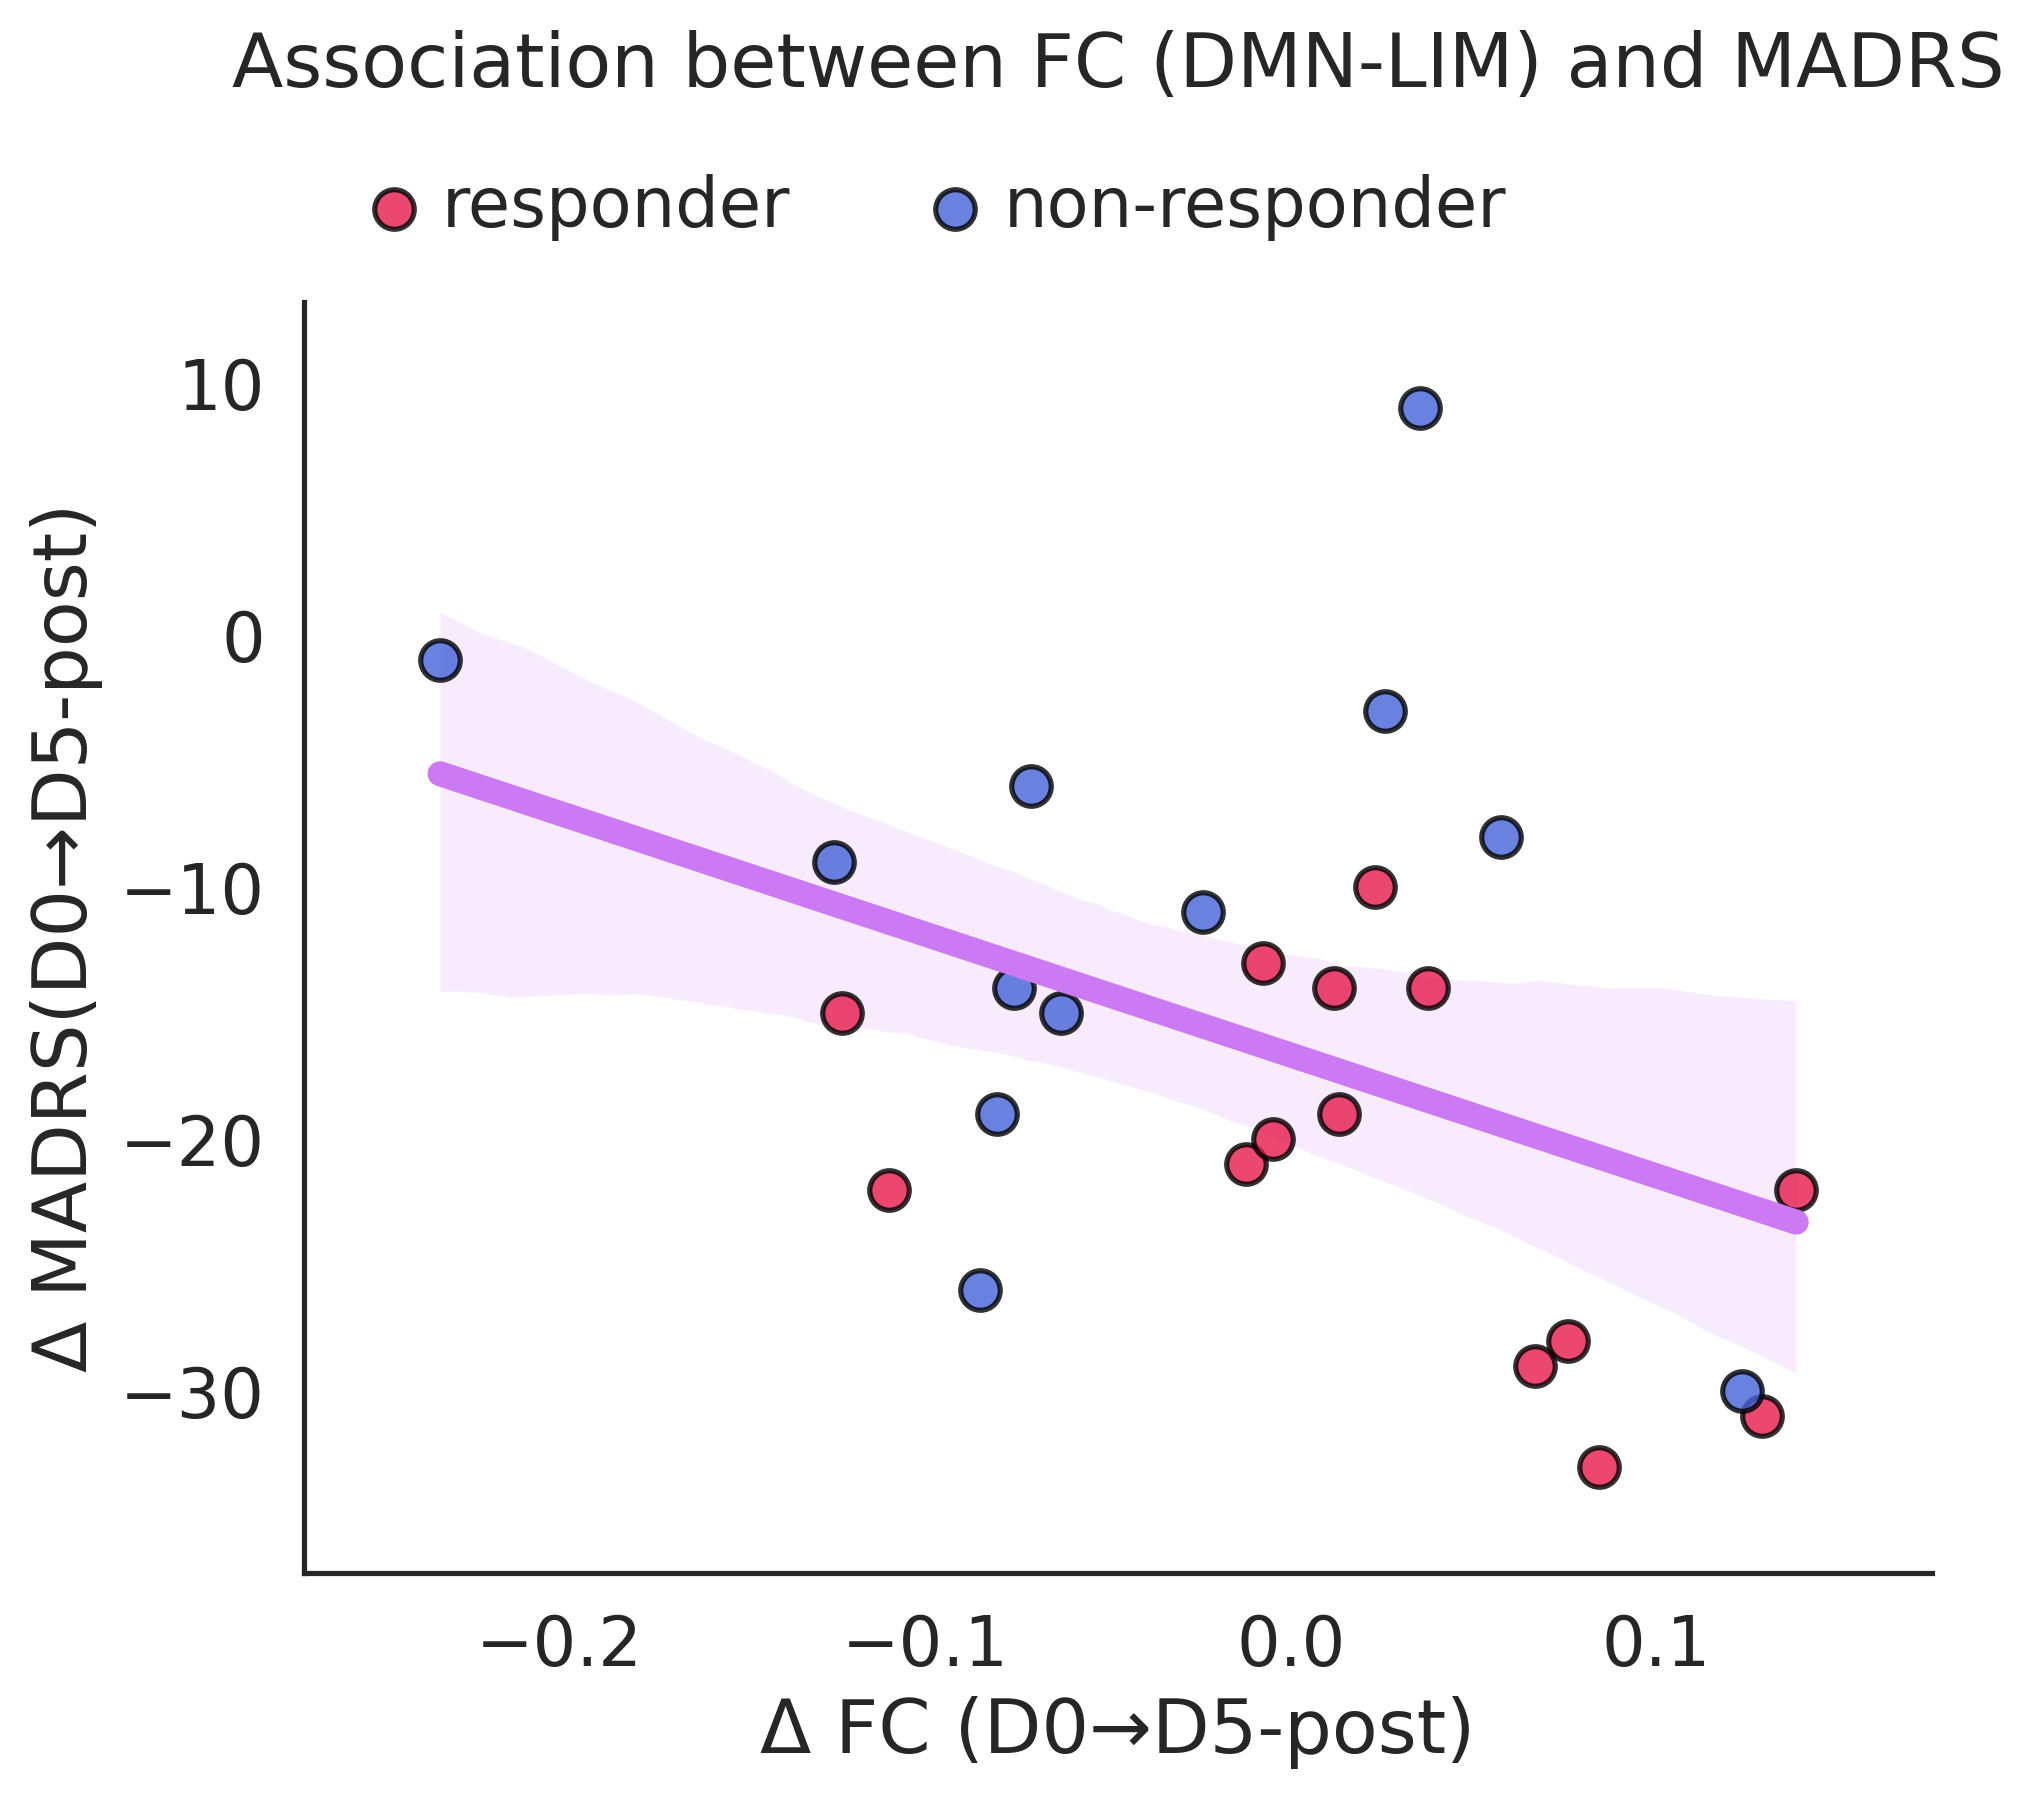

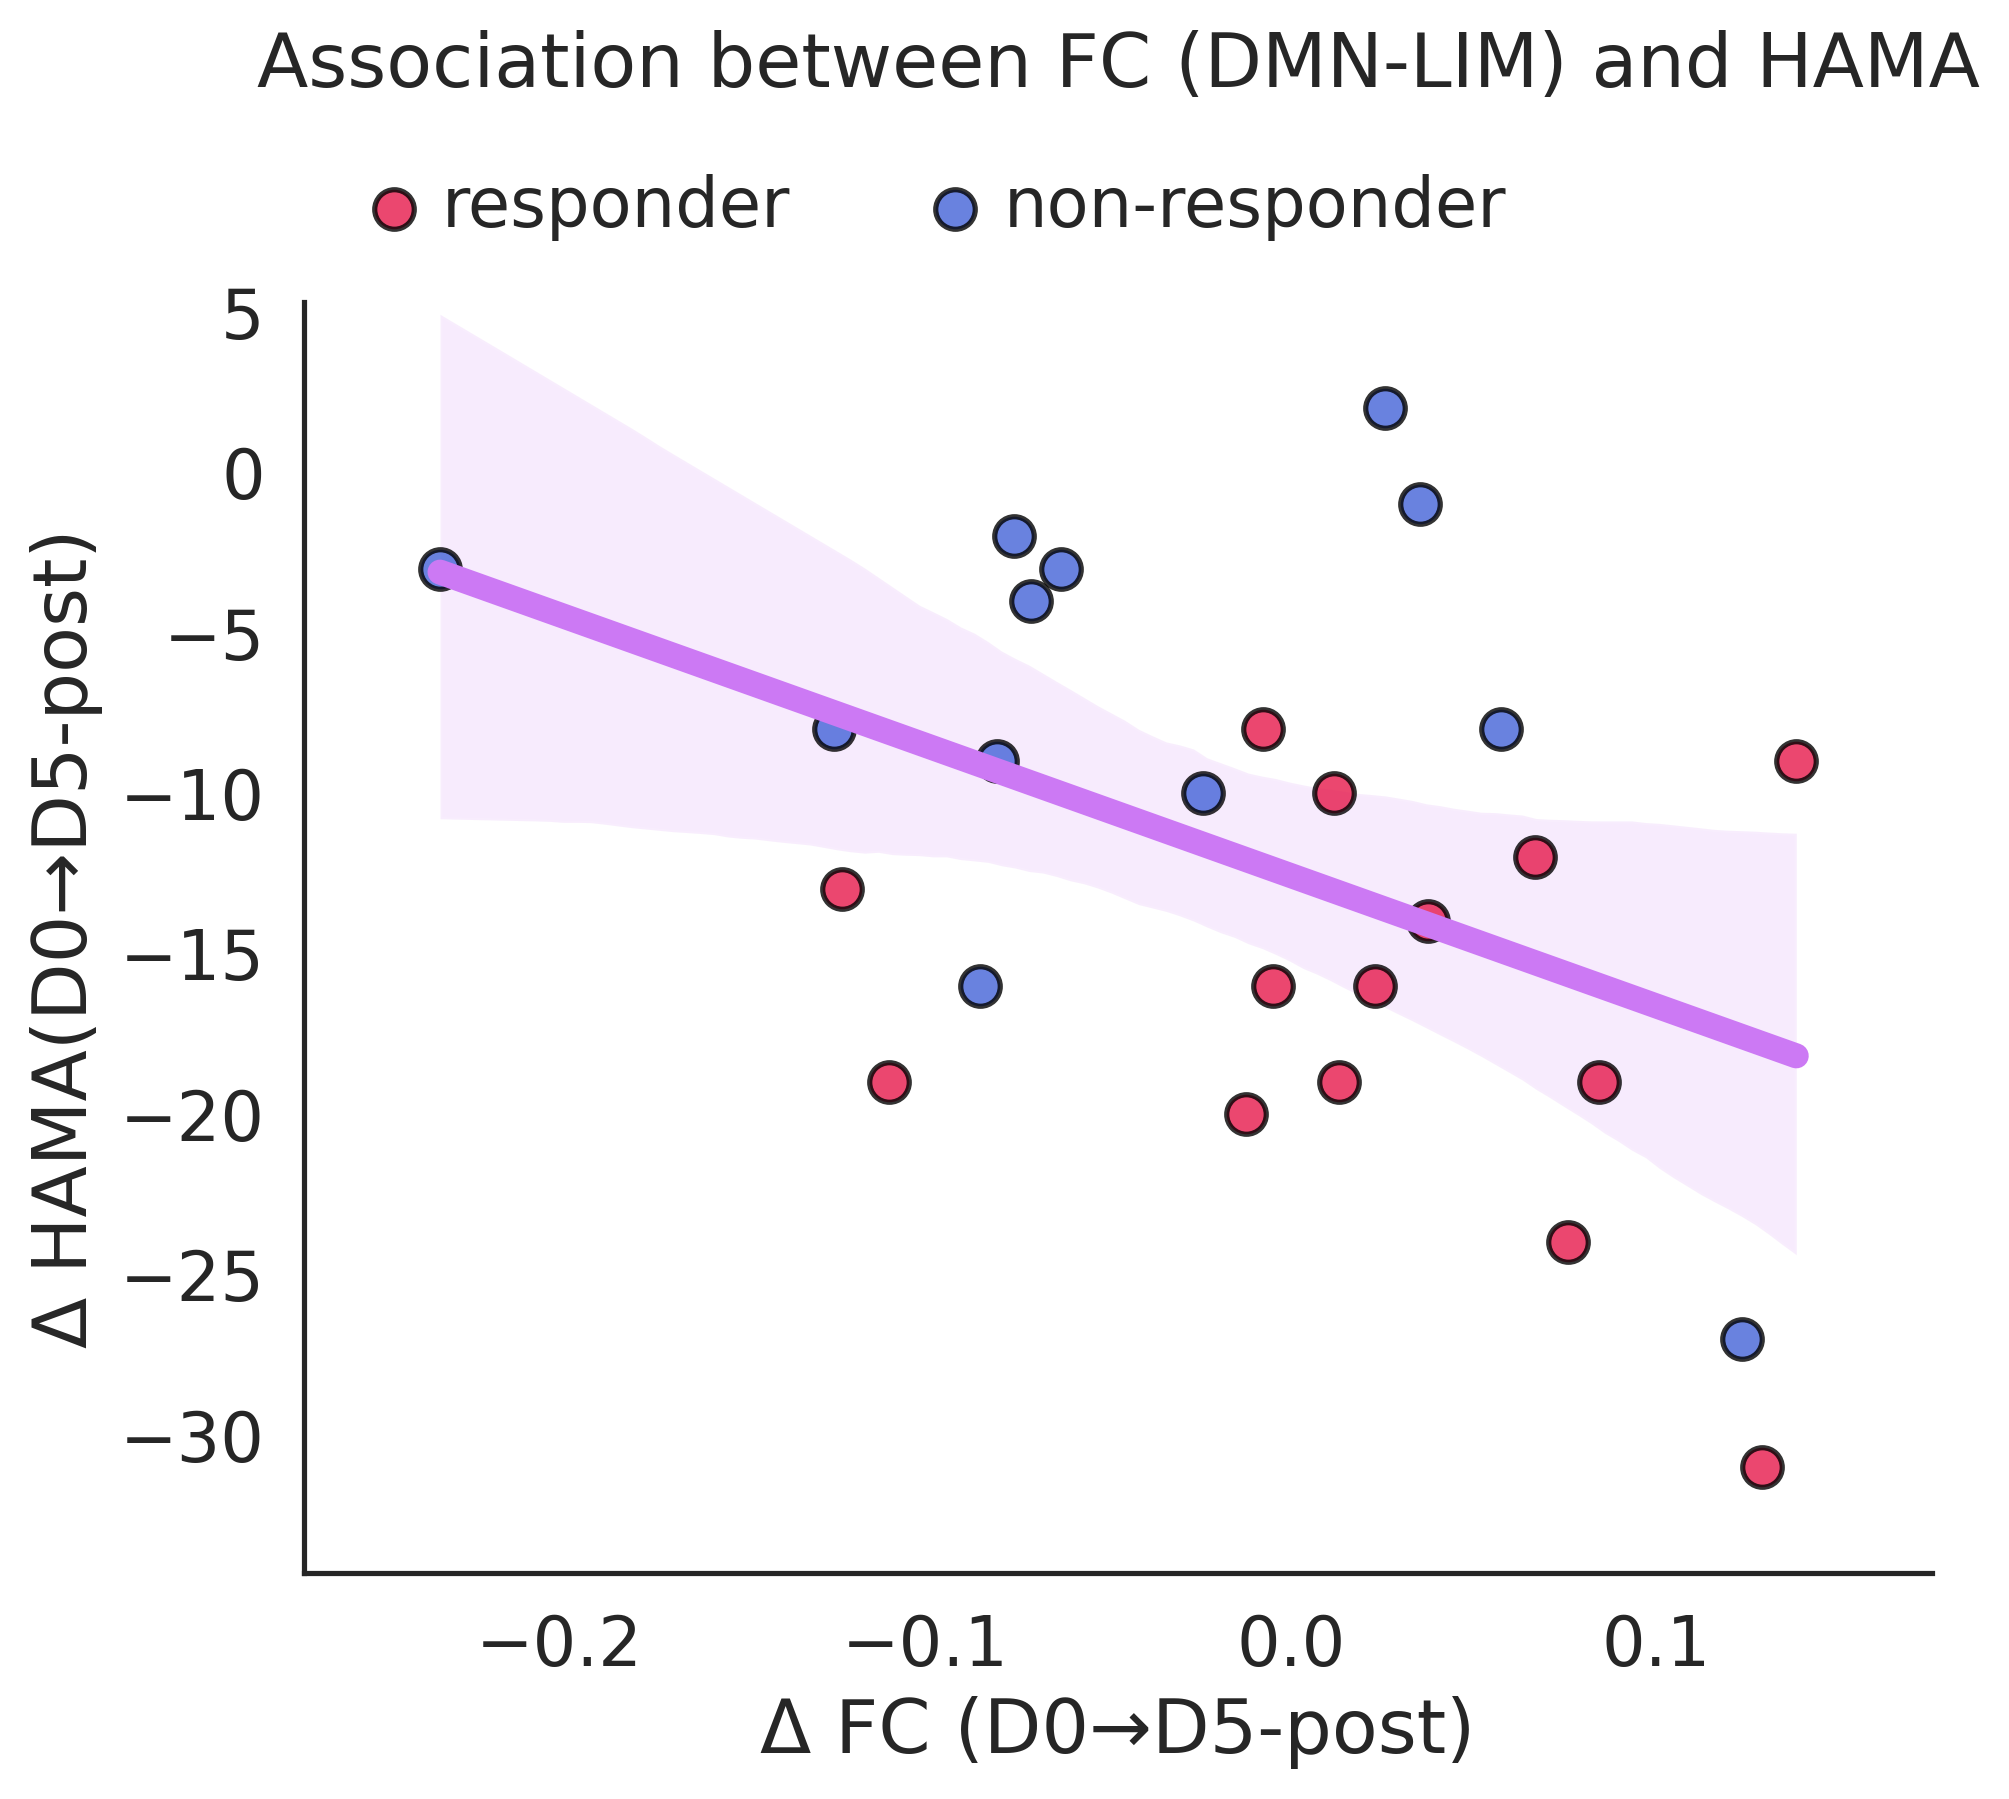

In [ ]:
# Compute partial correlation between ΔFC (DMN-LIM) and Δclinical scales
ses = '5th_after'
rsn = 'Default'

# Compute ΔFC (post − baseline) for the target RSN
fc = fc_df[fc_df['session'].isin(['baseline',ses])].pivot(index = 'id', columns = 'session', values = rsn)
fc = pd.DataFrame(fc.loc[:,ses] - fc.loc[:,'baseline'], columns = ['fc'])

# Use PSQI only for 4week session
cols = ['MADRS','HAMD','QIDS','HAMA'] if ses == '5th_after' else ['MADRS','HAMD','QIDS','HAMA','PSQI']

for scale_col in cols:
    # Compute Δscale (post − baseline)
    scale = match_scale(data = col_dict[scale_col].copy(), timepoint = ses).pivot(index = 'ID', columns = 'timepoint', values = scale_col)
    scale = pd.DataFrame(scale.loc[:,ses] - scale.loc[:,'baseline'], columns = ['scale'])
    
    # Merge FC, scale, demographics, and responder; partial correlation controlling for age & sex
    df = pd.concat([fc,scale,demo,responder.loc[:,'responder']], axis = 1).dropna(axis = 0)
    df.loc[df[df['sex'] == 'M'].index, 'sex'] = 1
    df.loc[df[df['sex'] == 'F'].index, 'sex'] = -1
    df['sex'] = df['sex'].astype(float)
    r,p = pg.partial_corr(data=df,x="fc",y="scale",covar=["age", "sex"],method="pearson" ).loc['pearson',['r','p-val']]
    print(f"{scale_col} r={r:.3f} p={p:.3f}")
    # If significant, plot the correlation with responder-colored scatter
    if(p<0.05):
        plot_corr_responder(df = df,x_col = 'fc',y_col = 'scale',
                    text=f'r={r:.3f} p={p:.3f}',xlabel=f'Δ FC (D0→D5-post)',ylabel=f'Δ {scale_col}(D0→D5-post)',
                    title=f'Association between FC (DMN-LIM) and {scale_col}')
        plt.savefig(f"DMN_LIM_{scale_col}.png",dpi = 300,bbox_inches='tight')


### **LIM - D5-post - Res/Non** 

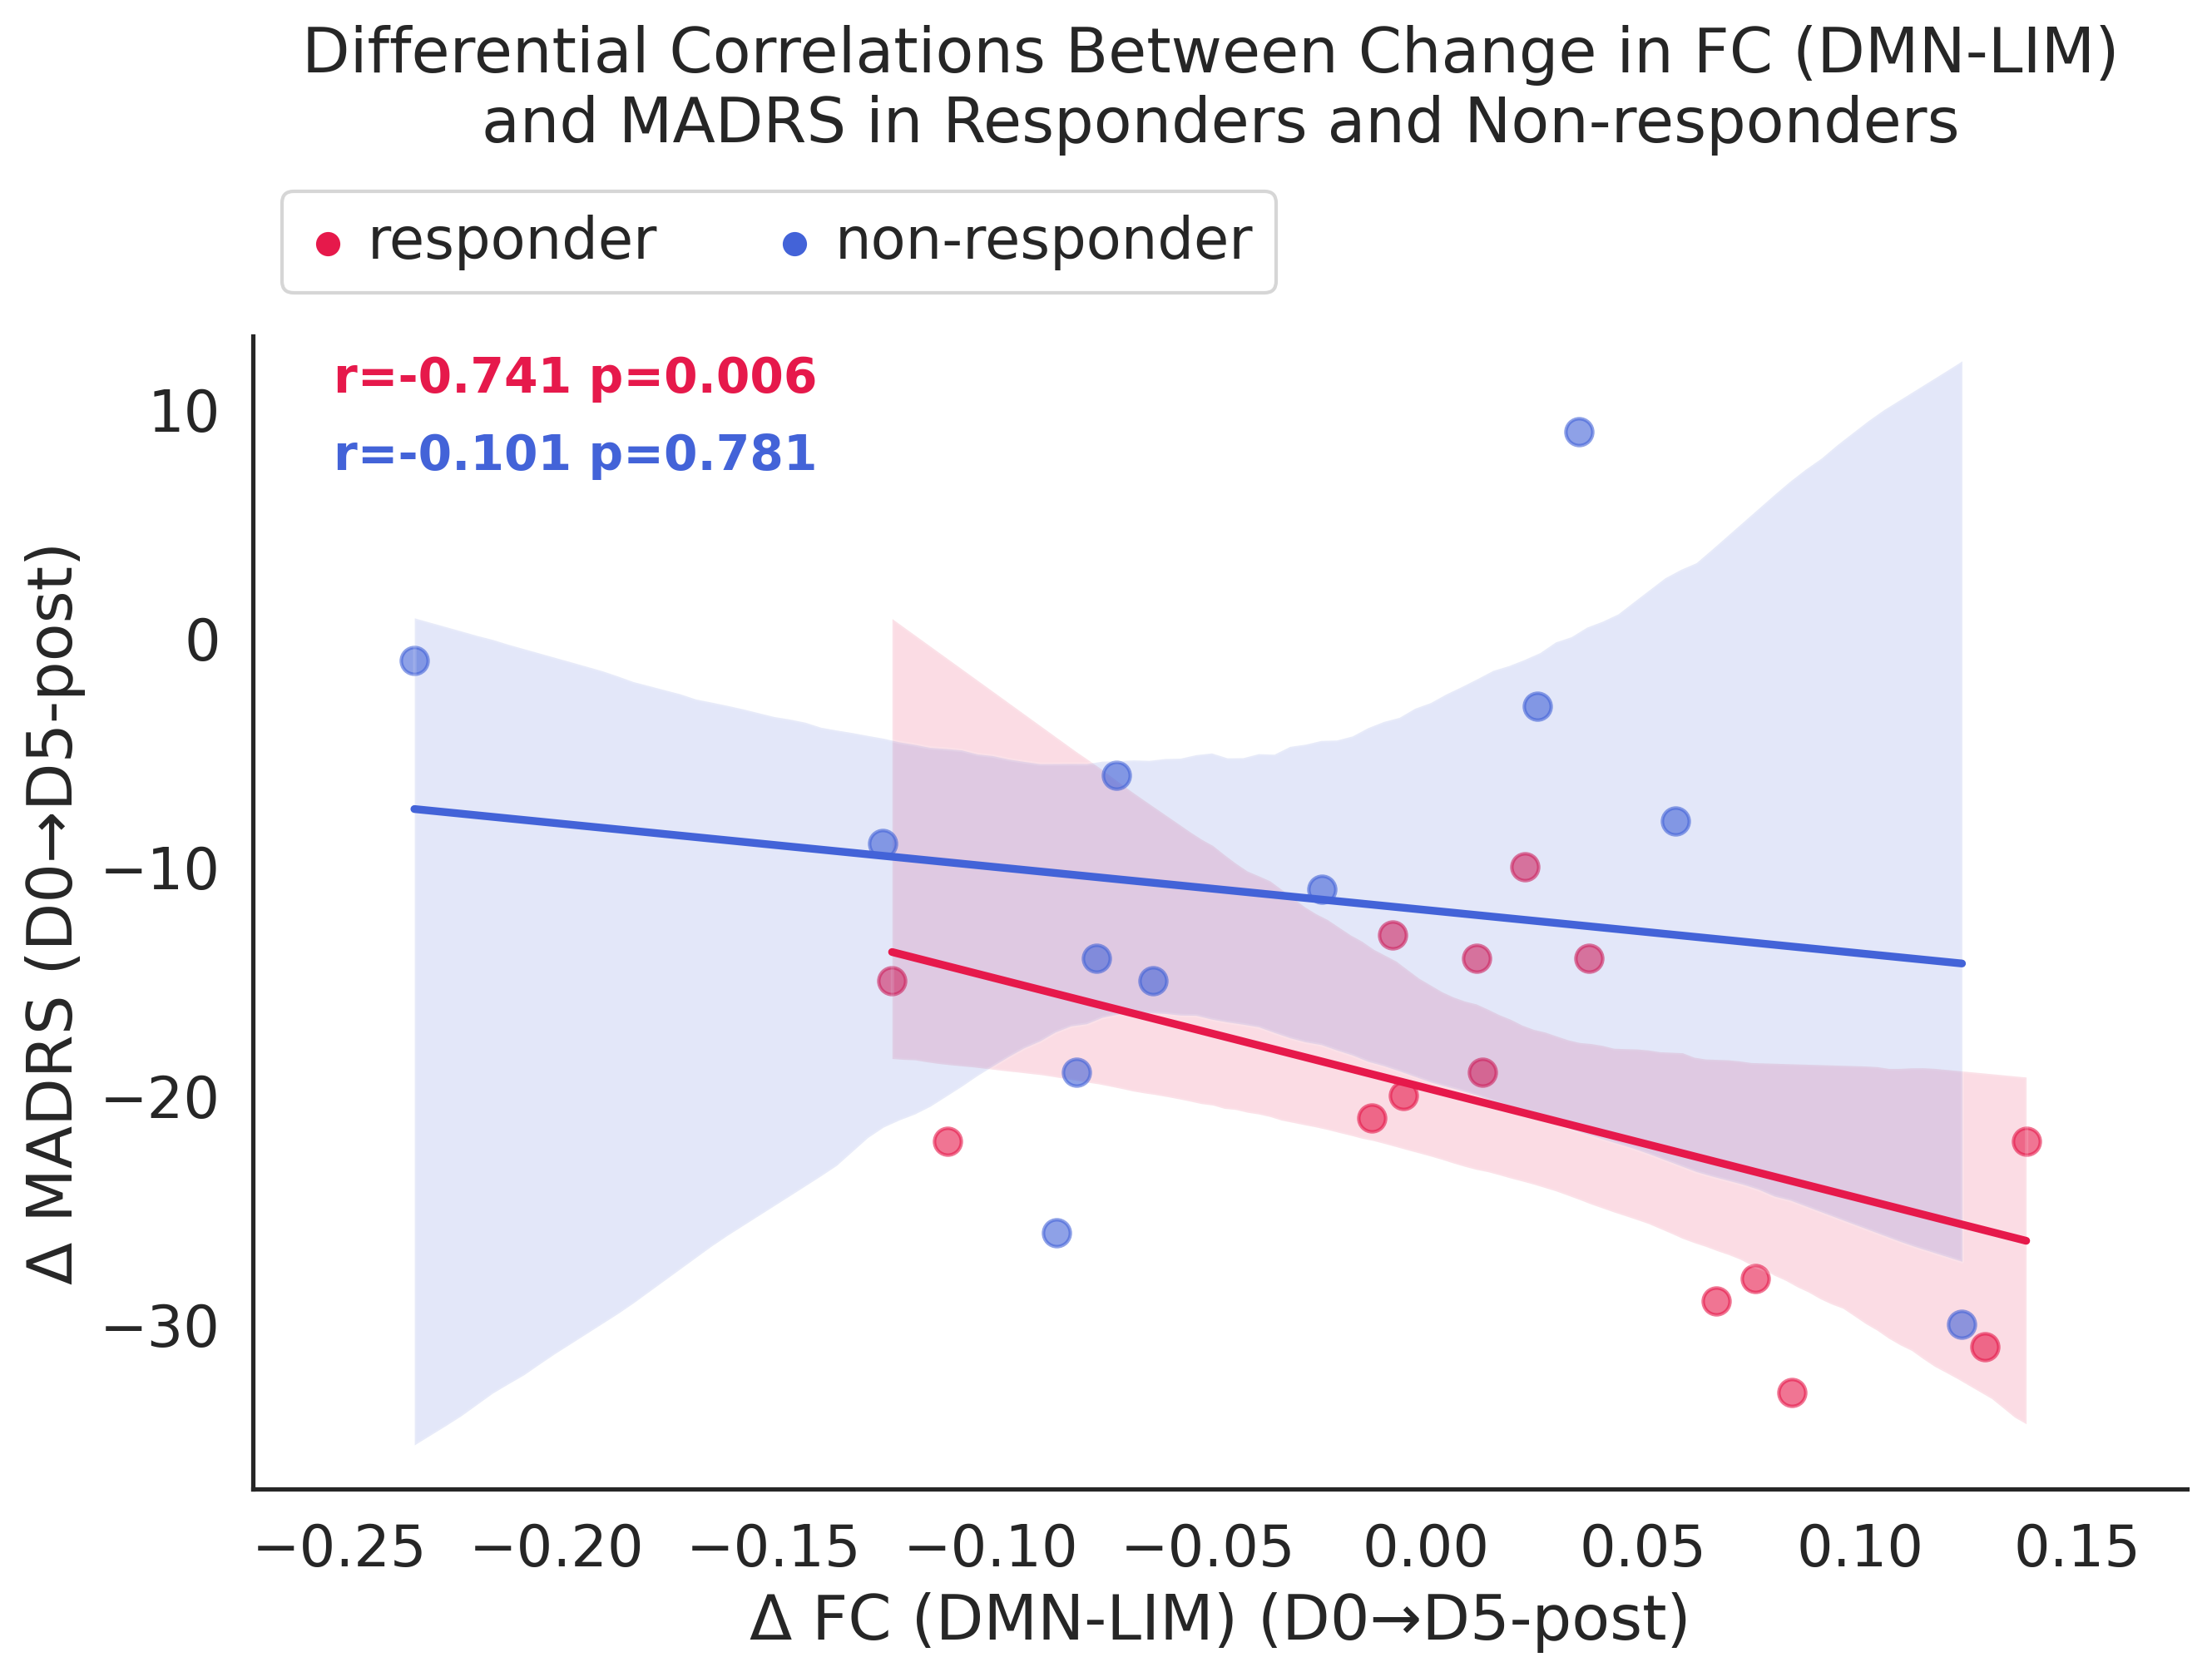

In [ ]:
# Differential correlations between ΔFC and ΔMADRS in responders vs non-responders
ses = '5th_after'
rsn = 'Default'

# Compute ΔFC (post − baseline)
fc = fc_df[fc_df['session'].isin(['baseline',ses])].pivot(index = 'id', columns = 'session', values = rsn)
fc = pd.DataFrame(fc.loc[:,ses] - fc.loc[:,'baseline'], columns = ['fc'])

# Compute ΔMADRS (post − baseline)
scale_col = 'MADRS'
scale = match_scale(data = col_dict[scale_col].copy(), timepoint = ses).pivot(index = 'ID', columns = 'timepoint', values = scale_col)
scale = pd.DataFrame(scale.loc[:,ses] - scale.loc[:,'baseline'], columns = ['scale'])
# Merge all data
df = pd.concat([fc,scale,demo,responder.loc[:,'responder']], axis = 1).dropna(axis = 0)
df.loc[df[df['sex'] == 'M'].index, 'sex'] = 1
df.loc[df[df['sex'] == 'F'].index, 'sex'] = -1
df['sex'] = df['sex'].astype(float)

# Split by responder status and compute partial correlations separately
res_df = df[df['responder']=='responder']
non_df = df[df['responder']=='non-responder']

r_res,p_res = pg.partial_corr(data=res_df,x="fc",y="scale",covar=["age", "sex"],method="pearson" ).loc['pearson',['r','p-val']]
r_non,p_non = pg.partial_corr(data=non_df,x="fc",y="scale",covar=["age", "sex"],method="pearson" ).loc['pearson',['r','p-val']]

# Plot separate regression lines for each group with correlation annotations
fig,ax = plt.subplots(figsize = (10,6),dpi = 300)
sns.regplot(data=res_df,x="fc",y="scale",ci=95, 
            scatter_kws={"facecolors":res_colors[0],"edgecolor": res_colors[0],"s": 60,'alpha':0.6},
            line_kws={"color": res_colors[0]} )
sns.regplot(data=non_df,x="fc",y="scale",ci=95, 
            scatter_kws={"facecolors":res_colors[1],"edgecolor": res_colors[1],"s": 60,'alpha':0.6},
            line_kws={"color": res_colors[1]} )

# Set axis limits with padding
x_max = np.max(df["fc"]);x_min = np.min(df["fc"]);x_range=x_max-x_min
y_max = np.max(df["scale"]);y_min = np.min(df["scale"]);y_range=y_max-y_min
plt.xlim(x_min-x_range*.1,x_max+x_range*.1)
plt.ylim(y_min-y_range*.1,y_max+y_range*.1)

# Annotate correlation coefficients for each group
plt.text(x_min-x_range*.05,y_max+y_range*.08,f"r={r_res:.3f} p={p_res:.3f}", color = res_colors[0],
         ha='left', va='top', fontsize = 14, fontweight = 'bold')
plt.text(x_min-x_range*.05,y_max-y_range*.0,f"r={r_non:.3f} p={p_non:.3f}", color = res_colors[1],
         ha='left', va='top', fontsize = 14, fontweight = 'bold')

plt.scatter([],[],color = res_colors[0], label = 'responder')
plt.scatter([],[],color = res_colors[1], label = 'non-responder')

plt.xlabel("Δ FC (DMN-LIM) (D0→D5-post)")
plt.ylabel(f"Δ {scale_col} (D0→D5-post)")
plt.title(f"Differential Correlations Between Change in FC (DMN-LIM) \nand {scale_col} in Responders and Non-responders", 
         y = 1.15)
plt.legend(bbox_to_anchor=(0, 1.15), loc='upper left', frameon=True,handlelength=0.8,handletextpad=0.3,ncol=2)
